**import libraries**

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import scipy

**load dataset**

In [44]:
df=pd.read_csv('C:/Users/ss/Downloads/Zomato-data-.csv')

In [15]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


In [17]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


**Data cleaning**

In [18]:
df.isnull().sum()
df.isna().sum()


name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

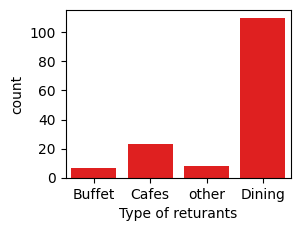

In [19]:
#1. Let's see the listed_in (type) column to identify popular restaurant categories.

plt.subplot(2,2,1)
sns.countplot (x=df['listed_in(type)'],color='r')
plt.xlabel('Type of returants');

In [20]:
#Votes by Restaurant Type,  Here we get the count of votes for each category

group_data = df.groupby('listed_in(type)')['votes'].sum()
group_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

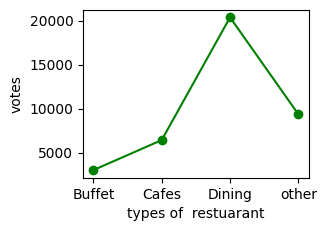

In [21]:
plt.subplot(2,2,1)
plt.plot(group_data,'o-g')
plt.xlabel('types of  restuarant')
plt.ylabel('votes');


In [22]:
# Find the restaurant with the highest number of votes.
the_highest=df['votes'].max()
x = df.loc[df['votes'] == the_highest, 'name']
x

38    Empire Restaurant
Name: name, dtype: str

In [23]:
import warnings
warnings.filterwarnings('ignore')

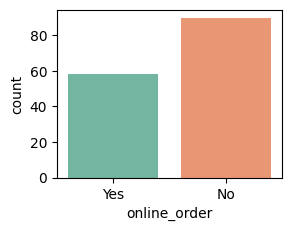

In [24]:
# Exploring the online_order column to see how many restaurants accept online orders.

plt.subplot(2,2,1)
sns.countplot(x=df['online_order'],palette='Set2');

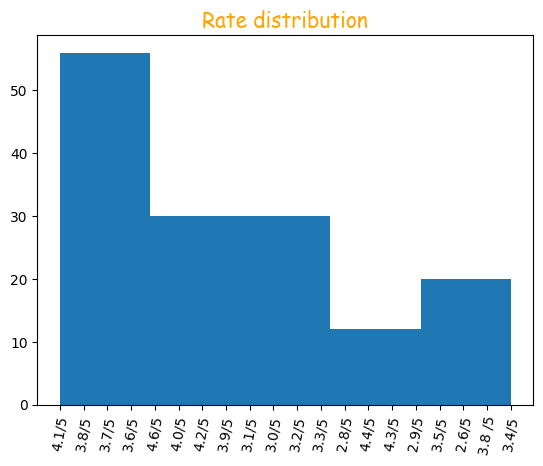

In [25]:
#Checking the distribution of ratings from the rate column.

 
plt.hist(df['rate'],bins=5)
plt.title('Rate distribution',fontdict={'color':'orange','size':15,'family':'cursive'})
plt.xticks(rotation=80);
 

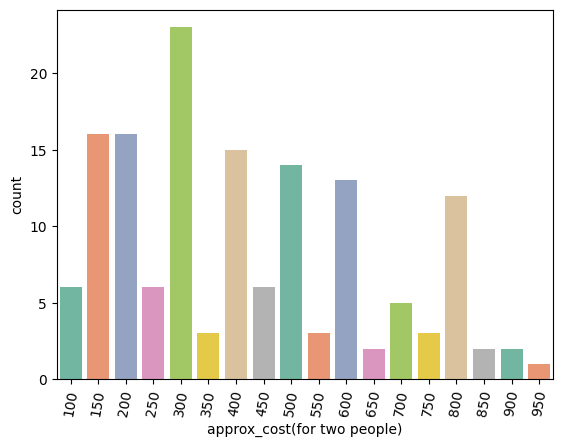

In [26]:
#Analyze the approx_cost(for two people) column to find the preferred price range.
a=df['approx_cost(for two people)']
sns.countplot(x=a,palette='Set2')
plt.xticks(rotation=80);

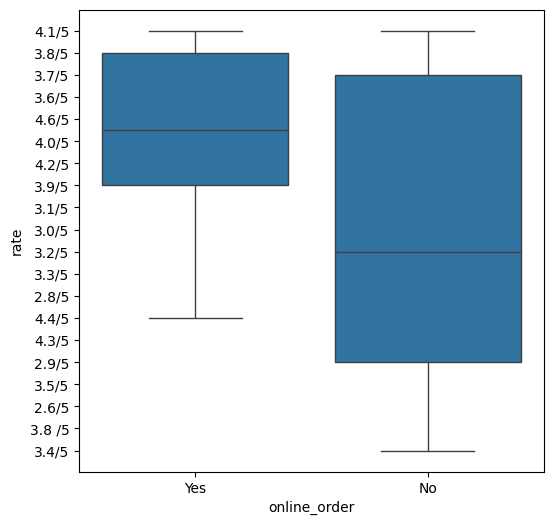

In [27]:
#Ratings Comparison - Online vs Offline Orders
plt.figure(figsize=(6,6))

sns.boxplot(x='online_order',y='rate',data=df);

**Dashboard**

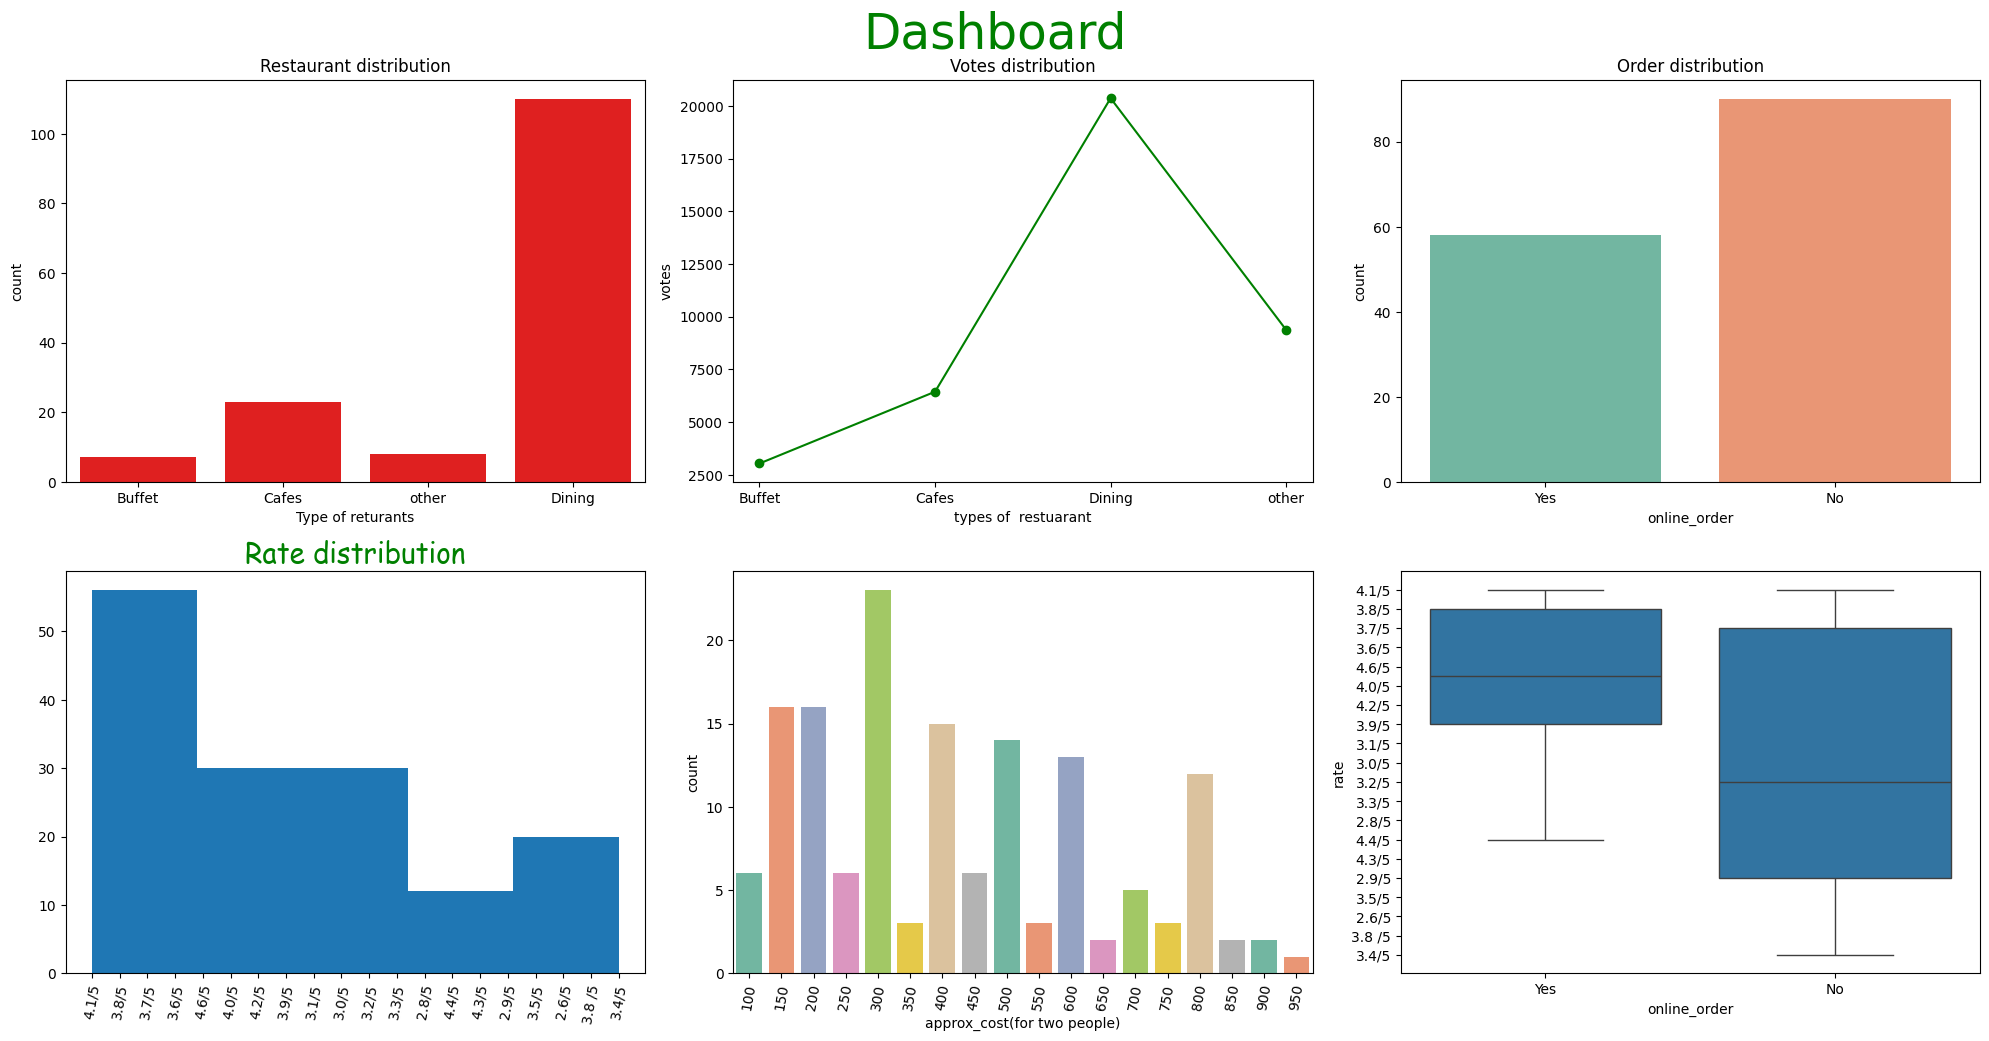

In [42]:
plt.figure(figsize=(20,15))

#1
plt.subplot(3,3,1)
sns.countplot (x=df['listed_in(type)'],color='r')
plt.xlabel('Type of returants')
plt.title('Restaurant distribution')

#2
plt.subplot(3,3,2)
plt.plot(group_data,'o-g')
plt.xlabel('types of  restuarant')
plt.ylabel('votes')
plt.title('Votes distribution')

#3
plt.subplot(3,3,3)
sns.countplot(x=df['online_order'],palette='Set2')
plt.title('Order distribution')

#4
plt.subplot(3,3,4)
plt.hist(df['rate'],bins=5)
plt.title('Rate distribution',fontdict={'color':'green','size':20,'family':'cursive'})
plt.xticks(rotation=80)

#5
plt.subplot(3,3,5)
a=df['approx_cost(for two people)']
sns.countplot(x=a,palette='Set2')
plt.xticks(rotation=80)

#6
plt.subplot(3,3,6)
sns.boxplot(x='online_order',y='rate',data=df)
plt.tight_layout(rect=[0,0,1,0.96])

#7
plt.suptitle('Dashboard',c='green',fontsize=35)
plt.tight_layout();